<figure style="text-align: center;">
  <img src="_static/intro/title_page.png" style="display: block; margin: 0 auto; width: 100%;">
</figure>

### Multiple Point Simulation

Michael J. Pyrcz, Professor, The University of Texas at Austin 

[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

Chapter of e-book "Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy". 

```{admonition} Cite this e-Book as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy* [e-book]. Zenodo. doi:10.5281/zenodo.15169133 [![DOI](https://zenodo.org/badge/838927017.svg)](https://doi.org/10.5281/zenodo.15169132)  
```

The workflows in this book and more are available here:

```{admonition} Cite the GeostatsPyDemos GitHub Repository as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *GeostatsPyDemos: GeostatsPy Python Package for Spatial Data Analytics and Geostatistics Demonstration Workflows Repository* (0.0.1) [Software]. Zenodo. doi:10.5281/zenodo.12667036. GitHub Repository: https://github.com/GeostatsGuy/GeostatsPyDemos [![DOI](https://zenodo.org/badge/777871341.svg)](https://doi.org/10.5281/zenodo.12667035)



```

By Michael J. Pyrcz <br />
&copy; Copyright 2024.

This chapter is a tutorial for / demonstration of  **Multiple Point Simulation (MPS)** for simulating spatial categorical features, e.g., like facies. 

* specifically, we use multiple point simulation to simulate categorical features and to produce models with heterogeneities more complicated than variogram-based methods.

**YouTube Lecture**: check out my lectures on:

* TBD

For your convenience here's a summary of salient points for MPS,

* Traditional geostatistics is primarily based on 2-point statistics (variograms / covariances), which effectively capture continuity but cannot fully represent complex spatial patterns, curvilinearity, connectivity, ordering relationships, i.e., complicated geological architecture.

* Multiple-point statistics (MPS) extend spatial modeling beyond 2-point relationships by using higher-order spatial patterns, multiple point patterns, i.e., > 2 points and typically with 5- and up to 20-points.  

* In practice, calculating reliable >2-point statistics directly from sparse subsurface data is generally impractical because the number of required spatial configurations grows combinatorially while conditioning data remain limited.

* MPS addresses this limitation through the training image paradigm, a TI provides a dense conceptual representation of expected geological patterns, connectivity, and morphology. The training image does not include local information nor conditioning and should be stationary with respect to the multiple point statistics and any other lower order statistics, e.g., proportions, indicator variogram (that includes Markov transition probabilities)

* Rather than explicitly computing all higher-order statistics, MPS reproduces spatial patterns by matching local data events to analogous patterns found in the TI. Multiple point matches are pooled to calculate the local conditional probability density function at each simulation location. 

* MPS conveniently integrates into the standard sequential simulation workflow, as a plug-and-play replacement for traditional indicator probability calculations in sequential indicator simulation, we replace the indicator kriging system with a training image scan (or search tree discussed below)

* Conditioning to well data, hard data pre-assigned to grid cells, and local constraints including soft data and trends updating local conditional probabilities is readily incorporated during sequential simulation, preserving compatibility with established geostatistical workflows.

* MPS is especially effective for categorical/facies modeling where geological realism, channel connectivity, and object morphology are critical.

* Due to its ability to reproduce realistic geological architectures, MPS is now widely adopted for facies simulation and reservoir characterization across subsurface resource industries, including petroleum, mining, groundwater, and carbon storage applications.

Additional details for advanced learning,

* MPS method demonstrated in this chapter is based on the earliest workflow developed by [Guardiano and Srivastava (1992)](https://link.springer.com/chapter/10.1007/978-94-011-1739-5_12). This workflow is typically infeasible for large models and large training images.

* [Strebelle (2002)](https://link.springer.com/article/10.1023/A:1014009426274) introduced the search tree from computer science for efficient prior to simulation, calculation, storage, and retrieval of all required multiple point conditional probability density functions. This major innovation enabled wide MPS adoption.

* modern MPS has evolved in many ways, for example, continuous in addition to categorical feature simulation, integrating machine learning embedding methods, training images from rule based models, etc.

Let's code up the simplest form of MPS for binary categorical simulation with a small 2D model and training image to help you learn the basics. 

#### Load the Required libraries

The following code loads the required libraries. 

In [1]:
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization and wrapper
import geostatspy.geostats as geostats                        # GSLIB methods convert to Python      
import geostatspy
print('GeostatsPy version: ' + str(geostatspy.__version__))  

GeostatsPy version: 0.0.71


We will also need some standard packages. These should have been installed with Anaconda 3.

In [2]:
import os                                                     # set working directory, run executables

from tqdm import tqdm                                         # suppress the status bar
from functools import partialmethod
tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)

ignore_warnings = True                                        # ignore warnings?
import numpy as np                                            # ndarrays for gridded data
import pandas as pd                                           # DataFrames for tabular data
import matplotlib.pyplot as plt                               # for plotting
import matplotlib.patches as patches
import matplotlib as mpl                                      # custom colorbar
import matplotlib.patches as mpatches                         # categorical legend

from matplotlib.colors import LinearSegmentedColormap         
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
plt.rc('axes', axisbelow=True)                                # plot all grids below the plot elements
if ignore_warnings == True:                                   
    import warnings
    warnings.filterwarnings('ignore')
cmap = plt.cm.inferno                                         # color map
seed = 42

If you get a package import error, you may have to first install some of these packages. This can usually be accomplished by opening up a command window on Windows and then typing 'python -m pip install [package-name]'. More assistance is available with the respective package docs. 

#### Define Functions

These are the fundamental functions required to calculate a multiple point simulation (MPS) realization, including,

* **plot_mps_template** - return the data even given the current node location and the data and previously simulated grid cells, with the option to plot the current simulation model with the data event highlighted in the grid

* **find_template_matches_TI** - scan the training image and find data event matches, return the matches and frequencies of each facies at the matches with the option to plot the matches (red dots) over the training image

* **template_match_probs_drop** - vectorized code for scanning the training image for data event matches, without visualization as a speed up for simulating all previous grid cells before the current visualized node

Along with convenience functions,

* **remove_unsimulated_cells_fixed** - add data to simulation model, and include any number of truth values to mimic a partially completed simulation if computational time is too long for a complete simulated realization

* **plot_simulated** - plot the simulation model with the new simulated realization added

* **plot_mps_pie** - plot the conditional PDF for facies given the data event and training image as a pie plot

In [3]:
def remove_unsimulated_cells_fixed(mini_model, df,nx, ny,xmin, xmax, ymin, ymax,n_unsim,seed=42):
    rng = np.random.default_rng(seed); dx = (xmax - xmin) / nx; dy = (ymax - ymin) / ny # convert coordinates → grid indices
    ix = ((df["X"].to_numpy() - xmin) / dx).astype(int); iy = ((df["Y"].to_numpy() - ymin) / dy).astype(int) 
    
    ix = np.clip(ix, 0, nx - 1); iy = np.clip(iy, 0, ny - 1)
    iy_np = (ny - 1) - iy                                     # flip y-axis for numpy indexing

    occupied = np.zeros((ny, nx), dtype=bool)                 # check for occupied grid node (with data)
    occupied[iy_np, ix] = True
    empty_cells = np.argwhere(~occupied)

    if len(empty_cells) == 0:
        raise ValueError("No empty cells available.")

    perm = rng.permutation(len(empty_cells))                  # fix random path ordering

    if n_unsim > len(empty_cells):
        raise ValueError("n_unsim exceeds number of empty cells")

    remove_cells = empty_cells[perm[:n_unsim]]                # apply removal
    out = mini_model.copy()       
    for j, i in remove_cells:
        out[j, i] = np.nan

    return out, remove_cells, empty_cells[perm]

def plot_mps_template(grid,template,ix, iy,xmin, xmax, ymin, ymax,title, plot_template, cmap, ax): # visualize template, return effective template
    ny, nx = grid.shape                                       # define grid 
    dx = (xmax - xmin) / nx; dy = (ymax - ymin) / ny
    if plot_template:
        im = ax.imshow(grid,extent=[xmin, xmax, ymin, ymax],cmap=cmap,alpha=0.85) # plot grid 
    effective_template = []                                   # build effective template (drop NaNs in grid)

    for k, (dix, diy) in enumerate(template):
        j = iy + diy; i = ix + dix
        if i < 0 or i >= nx or j < 0 or j >= ny:              # skip out-of-bounds
            continue
        if np.isnan(grid[j, i]):                              # skip unsimulated (NaN) grid cells
            continue
        effective_template.append((dix, diy))                 # draw only valid, informed points 
        x0 = xmin + i * dx; y0 = ymin + ((ny - j) - 1) * dy

        if plot_template:
            rect = patches.Rectangle((x0, y0),dx, dy,linewidth=2,edgecolor="black",facecolor="none")
            ax.add_patch(rect)
            if k > 0:
                ax.text(x0 + dx / 2,y0 + dy / 2,str(k),ha="center",va="center",fontsize=10,color="white",
                    fontweight="bold",zorder=100)
                
    if plot_template:
        cx = xmin + ix * dx; cy = ymin + ((ny - iy) - 1) * dy # center node
        rect = patches.Rectangle((cx, cy),dx, dy,linewidth=2,edgecolor="red",facecolor="none")
        ax.add_patch(rect)
        ax.set_title(title); ax.set_xlabel("X"); ax.set_ylabel("Y")
        cbar = plt.colorbar(im, ticks=[0, 1]); cbar.ax.set_yticklabels(["Shale", "Sand"]); cbar.set_label("Facies")
    return effective_template
    
def find_template_matches_TI(sim,TI,template,ix,iy,plot,title,cmap,ax): # find TI locations matching SIM-based conditioning pattern.
    ny, nx = TI.shape
    ref_pattern = []                                          # extract conditioning pattern from SIM
    for dix, diy in template:
        i_sim = ix + dix
        j_sim = iy + diy
        if i_sim < 0 or i_sim >= nx or j_sim < 0 or j_sim >= ny:
            return None, None
        ref_pattern.append(sim[j_sim, i_sim])
    ref_pattern = np.array(ref_pattern)

    matches = []                                              # scan for data event matches in TI
    for j in range(ny):
        for i in range(nx):
            ok = True
            for k, (dix, diy) in enumerate(template):
                if dix == 0 and diy == 0:
                    continue                   
                jj = j + diy
                ii = i + dix
                if ii < 0 or ii >= nx or jj < 0 or jj >= ny:
                    ok = False
                    break
                if TI[jj, ii] != ref_pattern[k]:
                    ok = False
                    break
            if ok:
                matches.append((j, i))
    matches = np.array(matches)

    if len(matches) > 0:                                      # compute proportions
        values = TI[matches[:, 0], matches[:, 1]]
        p0 = np.mean(values == 0); p1 = np.mean(values == 1)
    else:
        p0, p1 = np.nan, np.nan

    if plot:                                                  # plot
        im = ax.imshow(TI, cmap=cmap,extent=[xmin, xmax, ymin, ymax],alpha=0.85)
        x0_matches = xmin + matches[:,1] * cell_size + cell_size*0.5
        y0_matches = ymin + ((ny - matches[:,0]) - 1) * cell_size + cell_size*0.5    
        if len(matches) > 0:
            ax.scatter(x0_matches, y0_matches,c="red", s=20, label="matches")         
        ax.set_title(title); ax.set_xlabel("X"); ax.set_ylabel("Y")
        cbar = plt.colorbar(im, ticks=[0, 1]); cbar.ax.set_yticklabels(["Shale", "Sand"])
        cbar.set_label("Facies")
        
    return matches, {"facies_0": p0, "facies_1": p1}

def template_match_probs_drop(sim, TI, template, ix, iy):
    ny, nx = TI.shape
    template = list(template)
    if len(template) == 0:                                    # no conditioning data → global TI prior
        vals = TI.ravel()
        return np.mean(vals == 0), np.mean(vals == 1), vals.size, []

    def compute_probs(current_template):
        ref = []                                              # build data event from SIM (conditioning)
        for dix, diy in current_template:
            ii = ix + dix
            jj = iy + diy
            if ii < 0 or ii >= nx or jj < 0 or jj >= ny:
                return np.nan, np.nan, 0
            ref.append(sim[jj, ii])
        ref = np.array(ref)
        mask = np.ones((ny, nx), dtype=bool)                  # scan TI for matching patterns

        for k, (dix, diy) in enumerate(current_template):
            j0_src = max(0, -diy)
            j1_src = min(ny, ny - diy)
            i0_src = max(0, -dix)
            i1_src = min(nx, nx - dix)

            j0_dst = j0_src + diy
            j1_dst = j1_src + diy
            i0_dst = i0_src + dix
            i1_dst = i1_src + dix

            comp = np.zeros((ny, nx), dtype=bool)
            comp[j0_src:j1_src, i0_src:i1_src] = (TI[j0_dst:j1_dst, i0_dst:i1_dst] == ref[k])
            mask &= comp
            if not mask.any():
                return np.nan, np.nan, 0
        vals = TI[mask]

        if vals.size == 0:
            return np.nan, np.nan, 0
        return np.mean(vals == 0), np.mean(vals == 1), vals.size
        
    current_template = template.copy()                        # progressive template reduction

    while len(current_template) > 0:
        p0, p1, nmatch = compute_probs(current_template)
        if nmatch > 0:
            return p0, p1, nmatch, current_template
        current_template = current_template[:-1]
    vals = TI.ravel()                                         # fallback: global TI statistics
    return np.mean(vals == 0), np.mean(vals == 1), vals.size, []

def plot_mps_pie(n_matches, proportions, ax,labels=("shale", "sand"),colors=("lightgrey", "gold"),
    title="TI Match Proportions"):
    if n_matches == 0 or np.isnan(proportions["facies_0"]):   # handle empty case
        ax.text(0.5, 0.5, "No Matches",
                ha="center", va="center",
                fontsize=12)
        ax.set_axis_off()
        return

    p0 = proportions["facies_0"]; p1 = proportions["facies_1"] # calculate probabilities
    sizes = [p0, p1]
    counts = [int(round(p0 * n_matches)),int(round(p1 * n_matches))] # convert to counts

    def make_autopct(counts):                                 # autopct formatter (percent + count)
        def autopct(pct):
            idx = autopct.idx
            text = f"{pct:.1f}%\n(n={counts[idx]})"
            autopct.idx += 1
            return text
        autopct.idx = 0
        return autopct

    radius = 0.3 + 0.7 * min(n_matches / 50.0, 1.0)           # scale pie size by support

    ax.pie(sizes,labels=labels,colors=colors,startangle=90,autopct=make_autopct(counts), # plot
           radius=radius,wedgeprops={"edgecolor": "black"})
    ax.set_title(f"{title}\nN={n_matches}", fontsize=10)

def plot_simulated(grid,ix,iy,proportions,xmin,xmax,ymin,ymax,title,cmap,ax):
    ny, nx = grid.shape
    dx = (xmax - xmin) / nx
    dy = (ymax - ymin) / ny

    p1 = proportions["facies_1"]
    realization = int(np.random.random() < p1)

    new_grid = np.copy(grid)
    new_grid[iy,ix] = realization  
    
    im = ax.imshow(new_grid,extent=[xmin, xmax, ymin, ymax],cmap=cmap,alpha=0.85) # plot updated realization

    x0 = xmin + ix * dx; y0 = ymin + ((ny - iy) - 1) * dy
    rect = patches.Rectangle((x0, y0),dx, dy,linewidth=2,edgecolor="red",facecolor="none") # outline new realization
    ax.add_patch(rect)
    ax.set_title(title); ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
    cbar = plt.colorbar(im, ticks=[0, 1]); cbar.ax.set_yticklabels(["Shale", "Sand"])
    cbar.set_label("Facies")

def just_plot_simulated(grid,xmin,xmax,ymin,ymax,title,cmap,ax):   
    im = ax.imshow(grid,extent=[xmin, xmax, ymin, ymax],cmap=cmap,alpha=0.85) # plot updated realization
    ax.set_title(title); ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
    cbar = plt.colorbar(im, ticks=[0, 1]); cbar.ax.set_yticklabels(["Shale", "Sand"])
    cbar.set_label("Facies")

def copy_truth_values(cur_sim,truth,unsim,iunsim):            # copy truth values as "previously simulated grid cells", mimic partially simulated
    n = min(iunsim, len(unsim))                               # safety check
    for k in range(n-1):
        iy, ix = unsim[k]
        cur_sim[iy, ix] = truth[iy, ix]
    return cur_sim

def copy_truth_values(cur_sim,truth,unsim,iunsim):            # copy truth values as "previously simulated grid cells", mimic partially simulated
    n = min(iunsim, len(unsim))                               # safety check
    for k in range(n-1):
        iy, ix = unsim[k]
        cur_sim[iy, ix] = truth[iy, ix]
    return cur_sim

def sample_facies(matches_dict):                              # draws a random 0 or 1 based on the facies probabilities in the dictionary.
    outcomes = [0, 1]                                         # define the output choices corresponding to facies_0 and facies_1
    probabilities = [matches_dict['facies_0'], matches_dict['facies_1']] # extract probabilities from the specific keys
    return np.random.choice(outcomes, p=probabilities)        # return a single random selection

def sample_facies_fast(p0,p1):                                # draws a random 0 or 1 based on the facies probabilities in the dictionary.
    outcomes = [0, 1]                                         # define the output choices corresponding to facies_0 and facies_1
    probabilities = [p0,p1] # extract probabilities from the specific keys
    return np.random.choice(outcomes, p=probabilities)        # return a single random selection

#### Make Custom Colorbar

We make this colorbar to display our categorical binary spatial feature, sand and shale facies.

In [4]:
cmap_facies = mpl.colors.ListedColormap(['grey','gold'])      # sand and shale binary color map
cmap_facies.set_over('white'); cmap_facies.set_under('white')
cmap_facies_cont = LinearSegmentedColormap.from_list("cmap_facies_cont",["grey", "gold"],) # continuous color map variant

#### Set the Working Directory

I always like to do this so I don't lose files and to simplify subsequent read and writes (avoid including the full address each time). 

In [5]:
#os.chdir("c:/PGE383")                                        # set the working directory

#### Loading Data and Training Image

For our demonstration, we apply a small 2D model, training image and data set for efficient, fast simulation runs. This is all extracted from a large truth model to ensure consistency between data and training image. 

* small model, $n_x = 30$, $n_y = 20$

* training image, $n_x = 30$, $n_y = 20$

* data set, $n_{data} = 20$

Here's the,

* **truth model** (truth) - an exhaustive model that we extracted the data from that has similar spatial continuity as the training image (they are both extracted from different locations of the same larger model). I used this exhaustive truth model to ensure data and training image consistency (avoiding spatial contradictions). If your computer is slow, you can set, $n_unsim$ below to a number less than 580 ($n_x \times n_y - n_{data}$) and truth model values will be assigned as previously simulated grid cells along the random path. 

* **training image** (TI) - once again, extracted from the same larger model, it has consistent patterns with the simulation (from truth model) and the data (also from the truth model). Remember the training image has no data conditioning nor local information, i.e., it is an exhaustive model with the correct spatial correlation structures.

* **data set** (df) - extracted from the truth model, and below it is initialized to the simulation model (as is the first step with geostatistical sequential simulation).

Warning, for this demonstration we are assuming the simulation grid, truth grid and training image grid are all the same (same $n_x$ and $n_y$ and extents). 

* in practice the training image and simulation grid must have the same cell sizes, but may have different number of cells ($n_x$ and $n_y$)

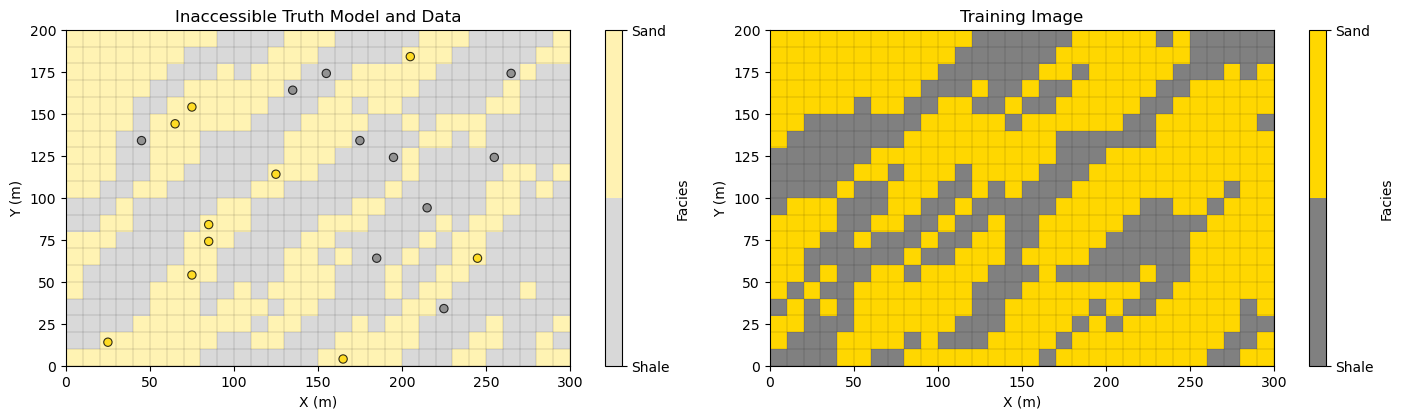

In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/2D_facies_minimodel_wells.csv") # load all from Dr. Pyrcz's GitHub 
truth = np.loadtxt(fname="https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/2D_facies_minimodel_array.csv", delimiter=",")  
TI = np.loadtxt(fname="https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/2D_facies_minimodel_array_v2.csv", delimiter=",")  
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization and wrapper
ny, nx = truth.shape                                          # get the mini-model grid parameters
cell_size = 10.0; xmin = 0.0; ymin = 0.0
xmax = xmin + nx*cell_size; ymax = ymin + ny*cell_size; 

plt.subplot(121)                                               # visualize the truth model with data, and the training image
cs = plt.imshow(truth,interpolation = None,extent = [xmin,xmax,ymin,ymax], vmin = 0.0, vmax = 1.0,alpha = 0.3,cmap = cmap_facies)      
x_edges = np.linspace(xmin, xmax, nx+1); y_edges = np.linspace(ymin, ymax, ny+1)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # horizontal andd vertical grid lines
plt.hlines(y_edges, xmin, xmax, colors="k", linewidth=0.2, alpha=0.5)

plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=0.0,vmax=1.0,
    alpha=0.8,linewidths=0.8,edgecolors="black",)

cbar = plt.colorbar(cs, ticks=[0, 1])
cbar.ax.set_yticklabels(["Shale", "Sand"])
cbar.set_label("Facies")

plt.title('Inaccessible Truth Model and Data'); plt.xlabel('X (m)'); plt.ylabel('Y (m)'); plt.tight_layout()

plt.subplot(122)
cs = plt.imshow(TI,interpolation = None,extent = [xmin,xmax,ymin,ymax], vmin = 0.0, vmax = 1.0,cmap = cmap_facies)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # horizontal andd vertical grid lines
plt.hlines(y_edges, xmin, xmax, colors="k", linewidth=0.2, alpha=0.5)

cbar = plt.colorbar(cs, ticks=[0, 1])
cbar.ax.set_yticklabels(["Shale", "Sand"])
cbar.set_label("Facies")

plt.title('Training Image'); plt.xlabel('X (m)'); plt.ylabel('Y (m)'); plt.tight_layout()

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.2, top=0.7, wspace=0.00, hspace=0.1); plt.show()

#### Set Up the Circumstances for a Step in Multiple Point Simulation

Now to illustrate multiple point simulation, let's,

1. make a copy of the truth model

2. remove a random set of values from the truth model (not at data locations)

Now we have set up the circumstances in the middle of the calculation of a multiple point simulation,

* data are assigned to nearest grid cells and are immutable during the simulation

* previously simulated values are assigned to grid cells and treated as data

* unsimulated values (future steps on the random path) are unsimulated (unassigned at this step)

If you would like to see the entire realization simulated, then used this setting so that only the data are assigned to the grid at the start of the simulation.

```python
n_unsim = 580
```

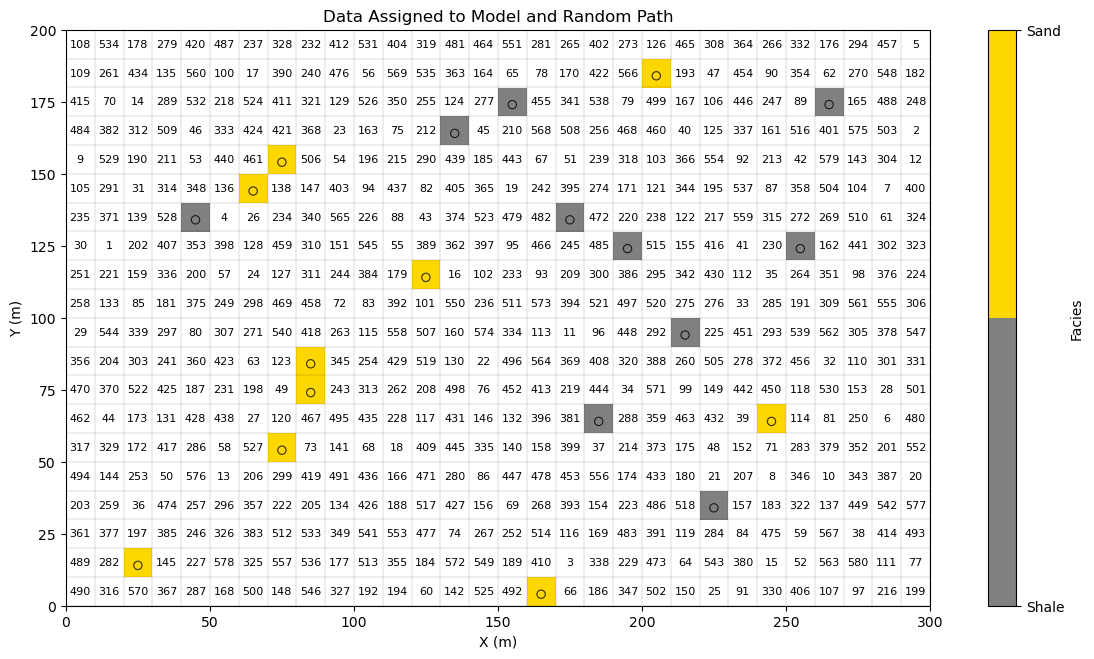

In [7]:
n_unsim = 580                                             # number of unsimulated grid cells in model (580 for only data in grid)
total_step = nx*ny - len(df)
step = total_step - n_unsim

sim, unsim, cells_empty  = remove_unsimulated_cells_fixed(truth,df,nx,ny,xmin,xmax,ymin,ymax,n_unsim,seed=seed) # assign unsimulated

plt.subplot(111)                                           # visualize current step in MPS sequential path
cs = plt.imshow(sim,interpolation = None,extent = [xmin,xmax,ymin,ymax], vmin = 0.0, vmax = 1.0,cmap = cmap_facies)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # horizontal andd vertical grid lines
plt.hlines(y_edges, xmin, xmax, colors="k", linewidth=0.2, alpha=0.5)

plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=0.0,vmax=1.0,
    alpha=0.8,linewidths=0.8,edgecolors="black",)

cbar = plt.colorbar(cs, ticks=[0, 1]); cbar.ax.set_yticklabels(["Shale", "Sand"])
cbar.set_label("Facies")

for i, (iy, ix) in enumerate(unsim):                       # label random path in node centers
    k = nx*ny - (n_unsim - i) - 1
    x0 = xmin + ix * cell_size
    y0 = ymin + ((ny - iy) - 1) * cell_size
    plt.text(x0 + cell_size / 2,y0 + cell_size / 2,str(i+1),ha="center",va="center",fontsize=8,color="black",)

plt.title('Data Assigned to Model and Random Path'); plt.xlabel('X (m)'); plt.ylabel('Y (m)'); plt.tight_layout()
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.8, top=1.2, wspace=0.2, hspace=0.2); plt.show()

#### Perform Multiple Point Simulation 

Multiple point simulation is applied to calculate stochastic categorical realizations conditional to available data. The caclulation of a realization can be concisely expressed as a joint sampling of the random function,

$$
Z(\bf{u}), \bf{u} \in AOI
$$

where $\bf{u}$ is a location vector, $AOI$ is the set of all grid cells in the simulation model, and $Z$ is the feature of interest. 

This does not look too difficult, so let's expand it to gain an appreciation for the size of the problem.  

$$
P\big(Z(\mathbf{u}_1),Z(\mathbf{u}_1),\ldots Z(\mathbf{u}_{N-1}),Z(\mathbf{u}_N)\big) 
$$

This is a $N$ dimensional probability density function where $N$ is commonly greater than one million grid cells; therefore, this is typically a vast solution space, and this sampling is not possible. 

We use the recursive application of the multiplication rule, $P(A,B) = P(A \mid B)\,P(B)$ i.e., chain rule of probability, to make this practical,

$$
\begin{align*}
P\big(Z(\mathbf{u}_1),\ldots,Z(\mathbf{u}_N)\big)
&= P\big(Z(\mathbf{u}_N)\mid Z(\mathbf{u}_1),\ldots,Z(\mathbf{u}_{N-1})\big)\, P\big(Z(\mathbf{u}_1),\ldots,Z(\mathbf{u}_{N-1})\big) \\
&= P\big(Z(\mathbf{u}_N)\mid Z(\mathbf{u}_1),\ldots,Z(\mathbf{u}_{N-1})\big)\,
   P\big(Z(\mathbf{u}_{N-1})\mid Z(\mathbf{u}_1),\ldots,Z(\mathbf{u}_{N-2})\big)\,
   P\big(Z(\mathbf{u}_1),\ldots,Z(\mathbf{u}_{N-2})\big) \\
&= P\big(Z(\mathbf{u}_N)\mid Z(\mathbf{u}_1),\ldots,Z(\mathbf{u}_{N-1})\big)\,
   P\big(Z(\mathbf{u}_{N-1})\mid Z(\mathbf{u}_1),\ldots,Z(\mathbf{u}_{N-2})\big)\,
   \cdots \,
   P\big(Z(\mathbf{u}_2)\mid Z(\mathbf{u}_1)\big)\,
   P\big(Z(\mathbf{u}_1)\big)
\end{align*}
$$

In words, the sequential simulation workflow proceeds by,

1. Monte Carlo simulate at the first grid cell location, $\bf{u}_1$ from the marginal probability density function, $P\big(Z(\mathbf{u}_1)\big)$

2. Monte Carlo simulate at the second grid cell location, $\bf{u}_2$ from the conditional probability density function, $P\big(Z(\mathbf{u}_2)\mid Z(\mathbf{u}_1)\big)$

3. Monte Carlo simulate at the third grid cell location, $\bf{u}_3$ from the conditional probability density function, $P\big(Z(\mathbf{u}_3)\mid Z(\mathbf{u}_2), Z(\mathbf{u}_1)\big)$ 

Given this sequential simulation paradigm, now let's walk through the steps in the case of multiple point simulation. Note, the multiple point template, training image and data events are applied to calculate these marginal and conditional probabilities to support our Monte Carlo simulation of local realizations that we put together to calculate the realization over all grid cells. Here are the steps with implementation details,

1. **Define the multiple point template** - the template is represented by a 2D array $[ n_{points}, \Delta^{ix,iy} ]$. For example, 2 points is the unknown location, $\Delta^{ix}_0 = 0$, $\Delta^{iy}_0 = 0$, with one other location relative to the unknown location, e.g., $\Delta^{ix}_1 = -1$, $\Delta^{iy}_1 = 1$ is up one cell and left one cell. 
  
$\quad$ The multiple point template is defined as,

$$
\tau = \{\bf{h}_{1}, \bf{h}_{2}, \ldots, \bf{h}_{m}\}
$$

$\quad$ where each $\bf{h}_i$ is an offset in grid cells from the unknown location, $\Delta^{ix}_i, \Delta^{iy}_i,$.

<figure style="text-align: center;">
  <img src="_static/mps/mp_template.png" style="display: block; margin: 0 auto; width: 30%;">
  <figcaption style="text-align: center;"> Example multiple point template with 5 points, including the tail, unknown, location.
</figcaption>
</figure>

$\quad$ For the example, below we have a 5 point multiple point template with the unknown location and all the adjacent cells on each face,

$$
\mathbf{\tau} =
\begin{bmatrix}
\Delta^{ix}_0 & \Delta^{iy}_0 \\
\Delta^{ix}_1 & \Delta^{iy}_1 \\
\Delta^{ix}_2 & \Delta^{iy}_2 \\
\Delta^{ix}_3 & \Delta^{iy}_3 \\
\Delta^{ix}_4 & \Delta^{iy}_4
\end{bmatrix}
=
\begin{bmatrix}
0 & 0 \\
-1 & 0 \\
1 & 0 \\
0 & -1 \\
0 & 1
\end{bmatrix}
$$

$\quad$ For clarity, here is an illustration of this multiple point template,

<figure style="text-align: center;">
  <img src="_static/mps/mp_template_verysimple.png" style="display: block; margin: 0 auto; width: 10%;">
  <figcaption style="text-align: center;"> Example multiple point template with 5 points, including the tail, unknown, location, and adjacent cells on each face.
</figcaption>
</figure>


2. **Visit a location along the random path** - sequentially visit grid cells (without assigned data) along the random path. The random (instead of ordered) path is preferred to avoid path artifacts such as smearing of values along the path that will appear as striations, e.g., like you would see in an cereal crop field from an airplane window, due to variations in seeding and other treatments along the path of the tractor.

$\quad$ At grid cell $k$, along the random path conditioning information includes,

* hard data assigned to nearest grid cells, $z(\bf{u_{\alpha}}), \quad \forall \quad \alpha = 1, \ldots, n_{data}(\bf{u}_k)$, where $n_{data}(\bf{u}_k)$ is the number of data conditioning grid cell, $\bf{u}_k$
  
* previously simulated grid cells, $z(\bf{u_{\beta}}), \quad \forall \quad \beta = 1, \ldots, n_{sim}$, where $n_{sim}(\bf{u}_k)$ is the number of previously simulated grid cells conditioning grid cell, $\bf{u}_k$


3. **Extract the multiple point data event** - at the current location along the random path apply the multiple point template, $\tau$, and extract the multiple point data event from the simulation model for template locations, $\bf{u}_k+\bf{h}_1 \ldots \bf{u}_k + \bf{h}_m$.

* note, the first point in the template, $\mathbf{u}_k$, is dropped from the multiple point data event as it is unknown and we are going to calculate the conditional probability distribution for it given the data event. 

$\quad$ For a grid cell location along the random path, $\mathbf{u}_k$, the multiple-point event (data event) is the set of values extracted from the simulation grid at the template, $\tau$, locations:

$$
\mathbf{d}(\mathbf{\bf{u}_k}) =
\Big(
z(\mathbf{\bf{u}_k}+\mathbf{h}_1),
z(\mathbf{\bf{u}_k}+\mathbf{h}_2),
\ldots,
z(\mathbf{\bf{u}_k}+\mathbf{h}_m)
\Big)
$$

$\quad$ Here is an example 5 point data event,

<figure style="text-align: center;">
  <img src="_static/mps/data_event.png" style="display: block; margin: 0 auto; width: 50%;">
  <figcaption style="text-align: center;"> Example data event for the previous multiple point template with 5 points.
</figcaption>
</figure>

$\quad$ If any of the template, $\tau$, grid cells do not have a previously simulated node nor data, then it is dropped from the template. 

* For example, here is a reduced data event template, 

<figure style="text-align: center;">
  <img src="_static/mps/data_event_reduced.png" style="display: block; margin: 0 auto; width: 45%;">
  <figcaption style="text-align: center;"> Example reduced data event for the previous multiple point template with 4 points given 1 point was uninformed in the simulated grid by data nor previously simulated grid cell and is dropped.
</figcaption>
</figure>

* note, for the early grid cells along the random path it is quite likely that none of the points, $i = 1, \ldots, m$ in the multiple point template are informed by data nor previously simulated grid cells

* in this null data event case, all grid cells in the training image match and the resulting condition probability density function for each facies are the global proportions from the training image. But I'm getting ahead of myself as I demonstrate this below.


4. **Calculate the conditional distribution from the training image** - scan the training image for replicates of the multiple point data event, and pool the observed feature categorical values at the first template location, $\bf{u}_k$,

$$
Z(\mathbf{u}_k) \sim f\Big(z(\mathbf{u}_k) \mid \mathbf{d}(\mathbf{u}_k)\Big)
$$

$\quad$ For categorical feature we can further specify the conditional probability density function at grid cell location $\mathbf{u}_k$ along the random path as,

$$
f_{z(\bf{u}_k)}) = P\Big(Z(\mathbf{u}_k) = C_k \mid \mathbf{d}(\mathbf{u}_k)\Big)
$$

5. **Monte Carlo simulation of a new realization at the current grid cell** - we have calculated the conditional probability density function, $f_{z(\bf{u}_k)})$, the final step is to perform Monte Carlo simulation, random sampling from this conditional probability density function to calculate a local realization $z^{\ell}(\bf{u}_k)$, 

$$
z^{\ell}(\bf{u}_k) = f^{-1}_{z(\bf{u}_k)}(p)
$$

$\quad$ where $p$ is a random number, $p \sim U[0,1]$

6. **Sequential update of the conditioning set** - after Monte Carlo simulation at location $\bf{u}_k$, this simulated value, $z^{\ell}(\bf{u}_k)$ is added to the grid as a previously simulated grid cell and is treated as data for any subsequent grid cells along the random path.

7. **Go to the next grid cell along the random path** - return to step 2 and proceed with the next grid cell along the random path. Repeat until all grid cells without assigned conditioning data have been visited.

#### Multiple Point Simulation Demonstration

In the follow code you can calculate a multiple point simulation realization and stop at any grid cell along the random path to visualize, 

* the current simulation grid with data and previously simulated grid cells all assigned as conditioning

* the random path order represented by a random path index

* the location of the current grid cell along the random path

* the data event extracted at the current grid cell

* the matches for the data event in the training image

* the updated simulation model with the local realization at the current grid cell added

You can update this line to change the current grid cell,

```python
current_node = 580
```
* select 1 to observe the multiple point sequential simulation process at the first grid cell along the random path to see the case with null data event and all grid cells in the training image match

* select 580 to observe the multiple point sequential simulation process at the last grid cell along the random path to see the case with a data event that includes all points in the multiple point template, an very few matches found in the training image.

Note, it is possible that data event is not found in the training image, the standard practice is to sequentially drop grid cells from the data event until matches are found to facilitate calculation of the conditional probability distribution.

#### Simulation at the First Grid Cell Along the Random Path

Let's look at the case of simulation at the first grid cell along the random path,

* due to the lack of previously simulated grid cells nor data in the template the data event is null

* all locations in the training image match

* the conditional probability density function is the global proportions of sand and shale

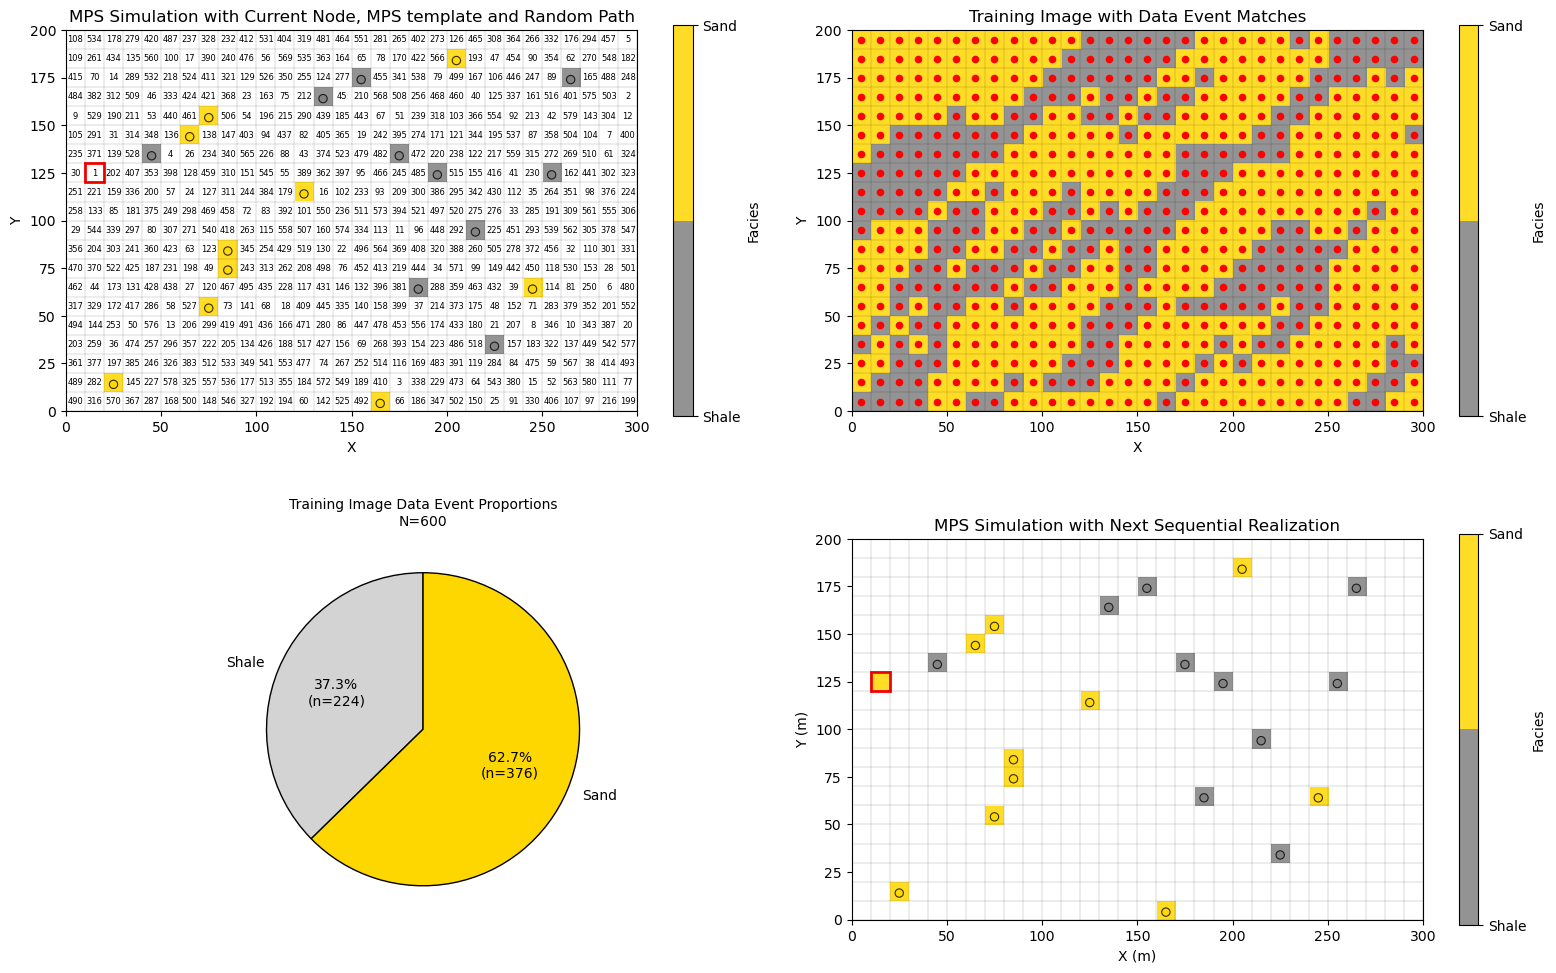

In [8]:
current_node = 1                                             # current simulation node (set from 1 to 580)

mps_template = [
    (0, 0),   # current node
    (-1, 0),  # left
    (1, 0),   # right
    (0, 1),   # up
    (0, -1),  # down
    (-1, -1),  # lower left
    (-1, 1),  # upper left
    (1, 1),  # upper right
    (1, -1)  # lower right
]

cur_sim = np.copy(sim)
np.random.seed(seed=seed)

for inode in range(1,current_node):                          # fast method for MPS over all previous grid cells
    current_loc = unsim[inode-1]
    current_mps_template = plot_mps_template(cur_sim,mps_template,ix=current_loc[1], iy=current_loc[0],xmin=0, xmax=300,
        ymin=0, ymax=200,title='MPS Simulation with Current Node, MPS template and Random Path',plot_template=False,cmap=cmap_facies,ax=None)
    p0, p1, nmatch, current_template = template_match_probs_drop(cur_sim, TI, current_mps_template,ix=current_loc[1],iy=current_loc[0])
    np.random.seed(seed=seed+inode)
    facies = sample_facies_fast(p0,p1)
    cur_sim[current_loc[0],current_loc[1]] = facies

inode = current_node-1                                       # now simulate the last node with all visualizations
current_loc = unsim[inode]
    
fig = plt.figure(figsize=(10,6))

ax1 = plt.subplot(2, 2, 1)                                   # plot the current simulation with data event for next node
current_mps_template = plot_mps_template(cur_sim,mps_template,ix=current_loc[1], iy=current_loc[0],xmin=0, xmax=300,
    ymin=0, ymax=200,title='MPS Simulation with Current Node, MPS template and Random Path',plot_template=True,cmap=cmap_facies,ax=ax1)

for i, (iy, ix) in enumerate(unsim):                         # label the random path
    k = nx*ny - (n_unsim - i) - 1
    x0 = xmin + ix * cell_size; y0 = ymin + ((ny - iy) - 1) * cell_size
    plt.text(x0 + cell_size / 2,y0 + cell_size / 2,str(i+1),ha="center",va="center",fontsize=6,color="black",)

x_edges = np.linspace(xmin, xmax, nx+1); y_edges = np.linspace(ymin, ymax, ny+1)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 
plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=-0.4,vmax=1.0,alpha=0.8,
    linewidths=0.8,edgecolors="black",)

ax2 = plt.subplot(2, 2, 2)                                   # plot the training image with all the data event matches
matches = find_template_matches_TI(cur_sim,TI,current_mps_template,ix=current_loc[1], iy=current_loc[0],plot=True,
    title="Training Image with Data Event Matches",ax=ax2,cmap = cmap_facies)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 

ax3 = plt.subplot(2, 2, 3)                                   # plot the observed fequencies at the matches
proportions = matches[1]; n_matches = len(matches[0])
plot_mps_pie(n_matches, proportions, ax3,labels=("Shale", "Sand"),colors=("lightgrey", "gold"),title="Training Image Data Event Proportions")

ax4 = plt.subplot(2, 2, 4)                                   # plot the updates simulated realization
plot_simulated(cur_sim,ix=current_loc[1], iy=current_loc[0],proportions=proportions,xmin=xmin,xmax=xmax,ymin=ymin,ymax=ymax,
    title="MPS Simulation with Next Sequential Realization",cmap=cmap_facies,ax=ax4)
plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=-0.4,vmax=1.0,alpha=0.8,
    linewidths=0.8,edgecolors="black",)

plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 

plt.subplots_adjust(left=0.0, bottom=0.0, right=1.5, top=1.5, wspace=0.1, hspace=0.3); 
plt.savefig("my_subplot_figure.png", dpi=300,bbox_inches="tight")
plt.show()

#### Simulation at a Grid Cell Along the Random Path

Let's look at the case of simulation at a grid cell about halfway along the random path,

* data event is partial, all grid cells in the multiple point template are not informed in the simulation grid

* moderate number of matches in the training image (the case of current_node = 300 there are only 31 matches) 

* conditional probability density function is the proportion of shale and sand at the training image matches (red dots in the plot)

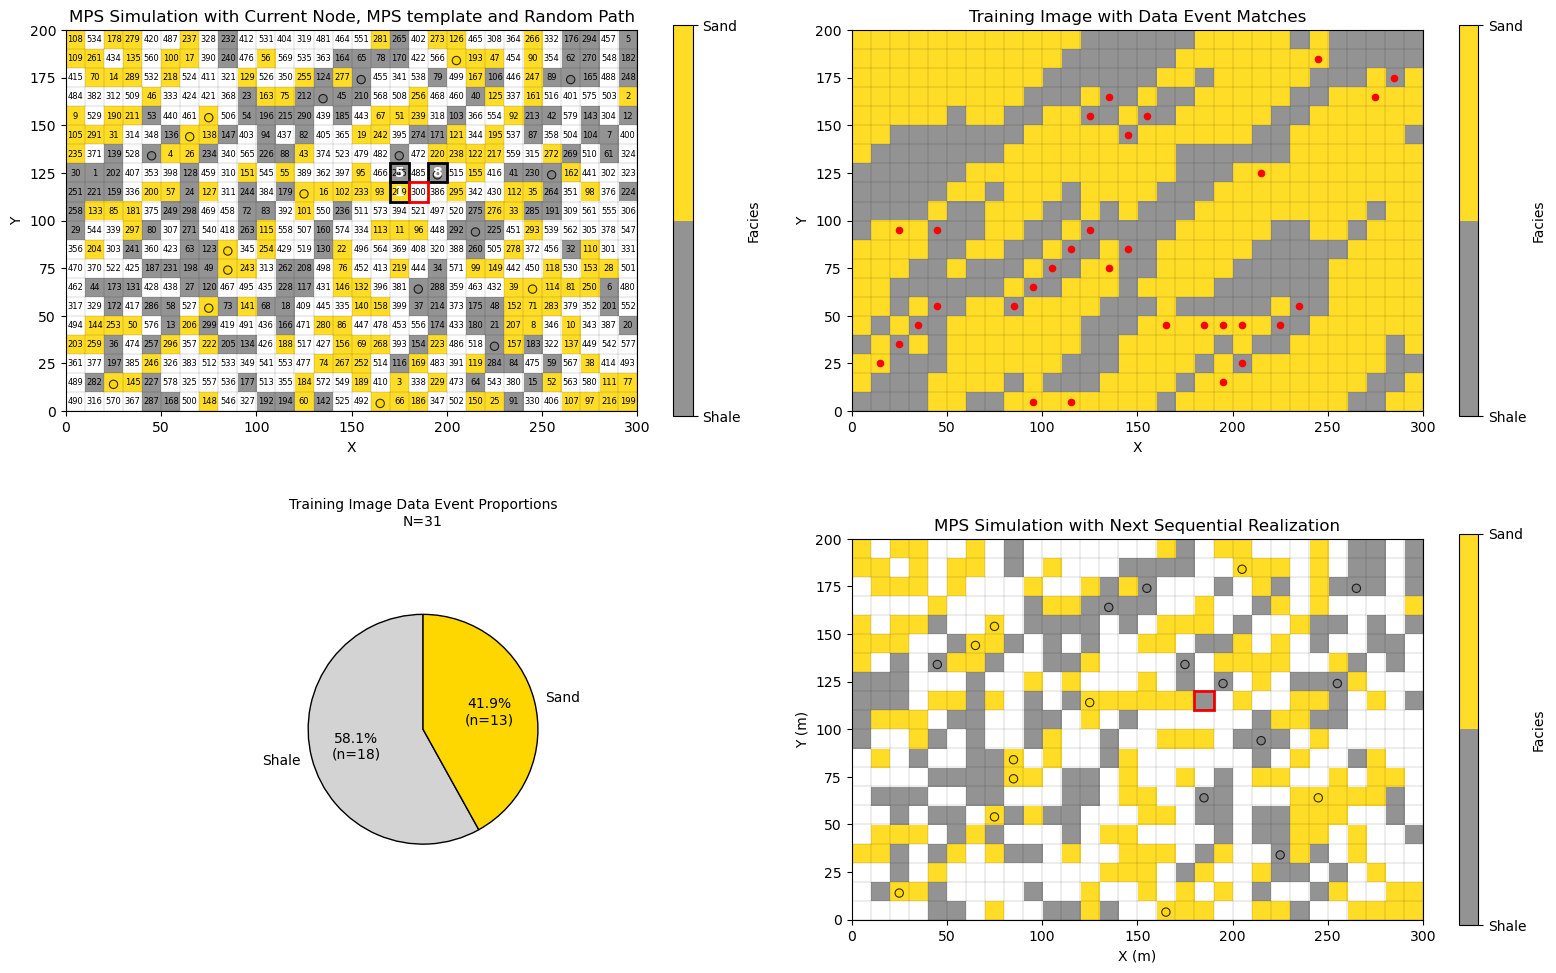

In [9]:
current_node = 300                                           # current simulation node (set from 1 to 580)

mps_template = [
    (0, 0),   # current node
    (-1, 0),  # left
    (1, 0),   # right
    (0, 1),   # up
    (0, -1),  # down
    (-1, -1),  # lower left
    (-1, 1),  # upper left
    (1, 1),  # upper right
    (1, -1)  # lower right
]

cur_sim = np.copy(sim)
np.random.seed(seed=seed)

for inode in range(1,current_node):                          # fast method for MPS over all previous grid cells
    current_loc = unsim[inode-1]
    current_mps_template = plot_mps_template(cur_sim,mps_template,ix=current_loc[1], iy=current_loc[0],xmin=0, xmax=300,
        ymin=0, ymax=200,title='MPS Simulation with Current Node, MPS template and Random Path',plot_template=False,cmap=cmap_facies,ax=None)
    p0, p1, nmatch, current_template = template_match_probs_drop(cur_sim, TI, current_mps_template,ix=current_loc[1],iy=current_loc[0])
    np.random.seed(seed=seed+inode)
    facies = sample_facies_fast(p0,p1)
    cur_sim[current_loc[0],current_loc[1]] = facies

inode = current_node-1                                       # now simulate the last node with all visualizations
current_loc = unsim[inode]
    
fig = plt.figure(figsize=(10,6))

ax1 = plt.subplot(2, 2, 1)                                   # plot the current simulation with data event for next node
current_mps_template = plot_mps_template(cur_sim,mps_template,ix=current_loc[1], iy=current_loc[0],xmin=0, xmax=300,
    ymin=0, ymax=200,title='MPS Simulation with Current Node, MPS template and Random Path',plot_template=True,cmap=cmap_facies,ax=ax1)

for i, (iy, ix) in enumerate(unsim):                         # label the random path
    k = nx*ny - (n_unsim - i) - 1
    x0 = xmin + ix * cell_size; y0 = ymin + ((ny - iy) - 1) * cell_size
    plt.text(x0 + cell_size / 2,y0 + cell_size / 2,str(i+1),ha="center",va="center",fontsize=6,color="black",)

x_edges = np.linspace(xmin, xmax, nx+1); y_edges = np.linspace(ymin, ymax, ny+1)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 
plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=-0.4,vmax=1.0,alpha=0.8,
    linewidths=0.8,edgecolors="black",)

ax2 = plt.subplot(2, 2, 2)                                   # plot the training image with all the data event matches
matches = find_template_matches_TI(cur_sim,TI,current_mps_template,ix=current_loc[1], iy=current_loc[0],plot=True,
    title="Training Image with Data Event Matches",ax=ax2,cmap = cmap_facies)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 

ax3 = plt.subplot(2, 2, 3)                                   # plot the observed fequencies at the matches
proportions = matches[1]; n_matches = len(matches[0])
plot_mps_pie(n_matches, proportions, ax3,labels=("Shale", "Sand"),colors=("lightgrey", "gold"),title="Training Image Data Event Proportions")

ax4 = plt.subplot(2, 2, 4)                                   # plot the updates simulated realization
plot_simulated(cur_sim,ix=current_loc[1], iy=current_loc[0],proportions=proportions,xmin=xmin,xmax=xmax,ymin=ymin,ymax=ymax,
    title="MPS Simulation with Next Sequential Realization",cmap=cmap_facies,ax=ax4)
plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=-0.4,vmax=1.0,alpha=0.8,
    linewidths=0.8,edgecolors="black",)

plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 

plt.subplots_adjust(left=0.0, bottom=0.0, right=1.5, top=1.5, wspace=0.1, hspace=0.3); plt.show()

#### Simulation at the Last Grid Cell Along the Random Path

Let's look at the case of simulation at the last grid cell along the random path,

* the data event is complete, all grid cells in the multiple point template are informed in the simulation grid

* generally smaller number of data event matches in the training image, i.e., 78 in this case

* the conditional probability density function the proportion of shale and sand at the training image matches (red dots in the plot)

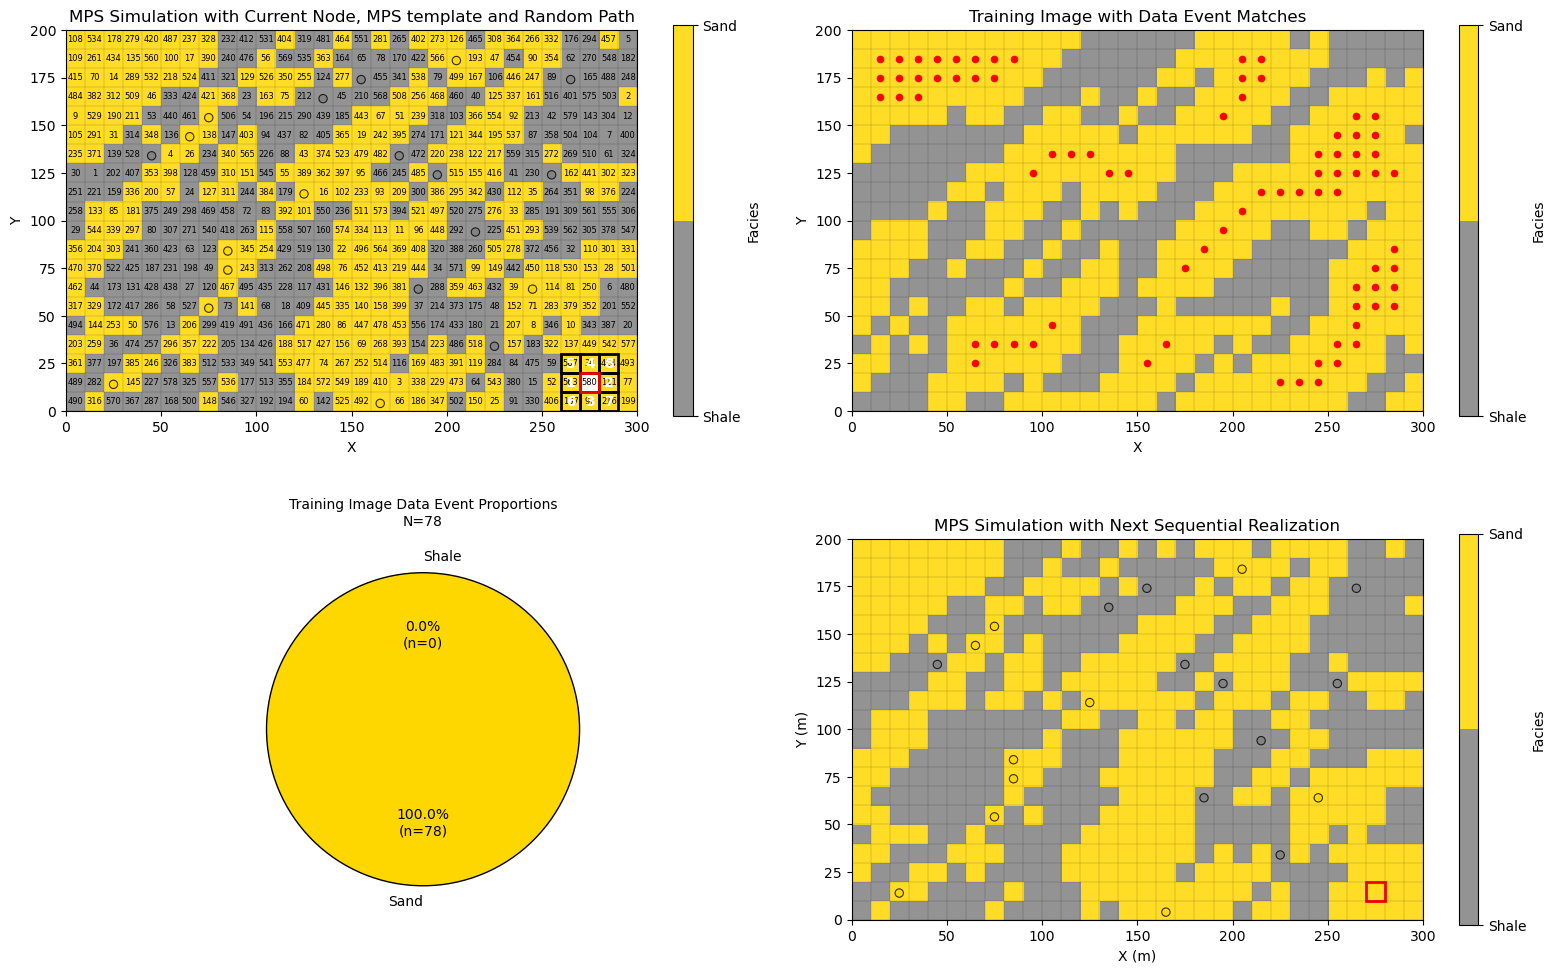

In [10]:
current_node = 580                                           # current simulation node (set from 1 to 580)

mps_template = [
    (0, 0),   # current node
    (-1, 0),  # left
    (1, 0),   # right
    (0, 1),   # up
    (0, -1),  # down
    (-1, -1),  # lower left
    (-1, 1),  # upper left
    (1, 1),  # upper right
    (1, -1)  # lower right
]

cur_sim = np.copy(sim)
np.random.seed(seed=seed)

for inode in range(1,current_node):                          # fast method for MPS over all previous grid cells
    current_loc = unsim[inode-1]
    current_mps_template = plot_mps_template(cur_sim,mps_template,ix=current_loc[1], iy=current_loc[0],xmin=0, xmax=300,
        ymin=0, ymax=200,title='MPS Simulation with Current Node, MPS template and Random Path',plot_template=False,cmap=cmap_facies,ax=None)
    p0, p1, nmatch, current_template = template_match_probs_drop(cur_sim, TI, current_mps_template,ix=current_loc[1],iy=current_loc[0])
    np.random.seed(seed=seed+inode)
    facies = sample_facies_fast(p0,p1)
    cur_sim[current_loc[0],current_loc[1]] = facies

inode = current_node-1                                       # now simulate the last node with all visualizations
current_loc = unsim[inode]
    
fig = plt.figure(figsize=(10,6))

ax1 = plt.subplot(2, 2, 1)                                   # plot the current simulation with data event for next node
current_mps_template = plot_mps_template(cur_sim,mps_template,ix=current_loc[1], iy=current_loc[0],xmin=0, xmax=300,
    ymin=0, ymax=200,title='MPS Simulation with Current Node, MPS template and Random Path',plot_template=True,cmap=cmap_facies,ax=ax1)

for i, (iy, ix) in enumerate(unsim):                         # label the random path
    k = nx*ny - (n_unsim - i) - 1
    x0 = xmin + ix * cell_size; y0 = ymin + ((ny - iy) - 1) * cell_size
    plt.text(x0 + cell_size / 2,y0 + cell_size / 2,str(i+1),ha="center",va="center",fontsize=6,color="black",)

x_edges = np.linspace(xmin, xmax, nx+1); y_edges = np.linspace(ymin, ymax, ny+1)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 
plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=-0.4,vmax=1.0,alpha=0.8,
    linewidths=0.8,edgecolors="black",)

ax2 = plt.subplot(2, 2, 2)                                   # plot the training image with all the data event matches
matches = find_template_matches_TI(cur_sim,TI,current_mps_template,ix=current_loc[1], iy=current_loc[0],plot=True,
    title="Training Image with Data Event Matches",ax=ax2,cmap = cmap_facies)
plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 

ax3 = plt.subplot(2, 2, 3)                                   # plot the observed fequencies at the matches
proportions = matches[1]; n_matches = len(matches[0])
plot_mps_pie(n_matches, proportions, ax3,labels=("Shale", "Sand"),colors=("lightgrey", "gold"),title="Training Image Data Event Proportions")

ax4 = plt.subplot(2, 2, 4)                                   # plot the updates simulated realization
plot_simulated(cur_sim,ix=current_loc[1], iy=current_loc[0],proportions=proportions,xmin=xmin,xmax=xmax,ymin=ymin,ymax=ymax,
    title="MPS Simulation with Next Sequential Realization",cmap=cmap_facies,ax=ax4)
plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=-0.4,vmax=1.0,alpha=0.8,
    linewidths=0.8,edgecolors="black",)

plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 

plt.subplots_adjust(left=0.0, bottom=0.0, right=1.5, top=1.5, wspace=0.1, hspace=0.3); plt.show()

#### Compare Multiple Realizations

Now let's specify 4 random seeds (integers) and repeat the code above 4 times and just visualize the simulated realizations.

* I know that I should streamline this code by adding a proper multiple point simulation function to GeostatsPy.

For now, I reuse the code above as we can see all the components to make new realizations, the change in random number seed,

* changes the random path through the grid cells without assigned data

* changes the Monte Carlo simulations from the conditional probability density functions at each grid cell without assigned data

For each realization let's visualize the,

* facies realizations at each grid cell

* data locations to confirm the realizations are conditional

* random path to confirm that the random path changes for each realization

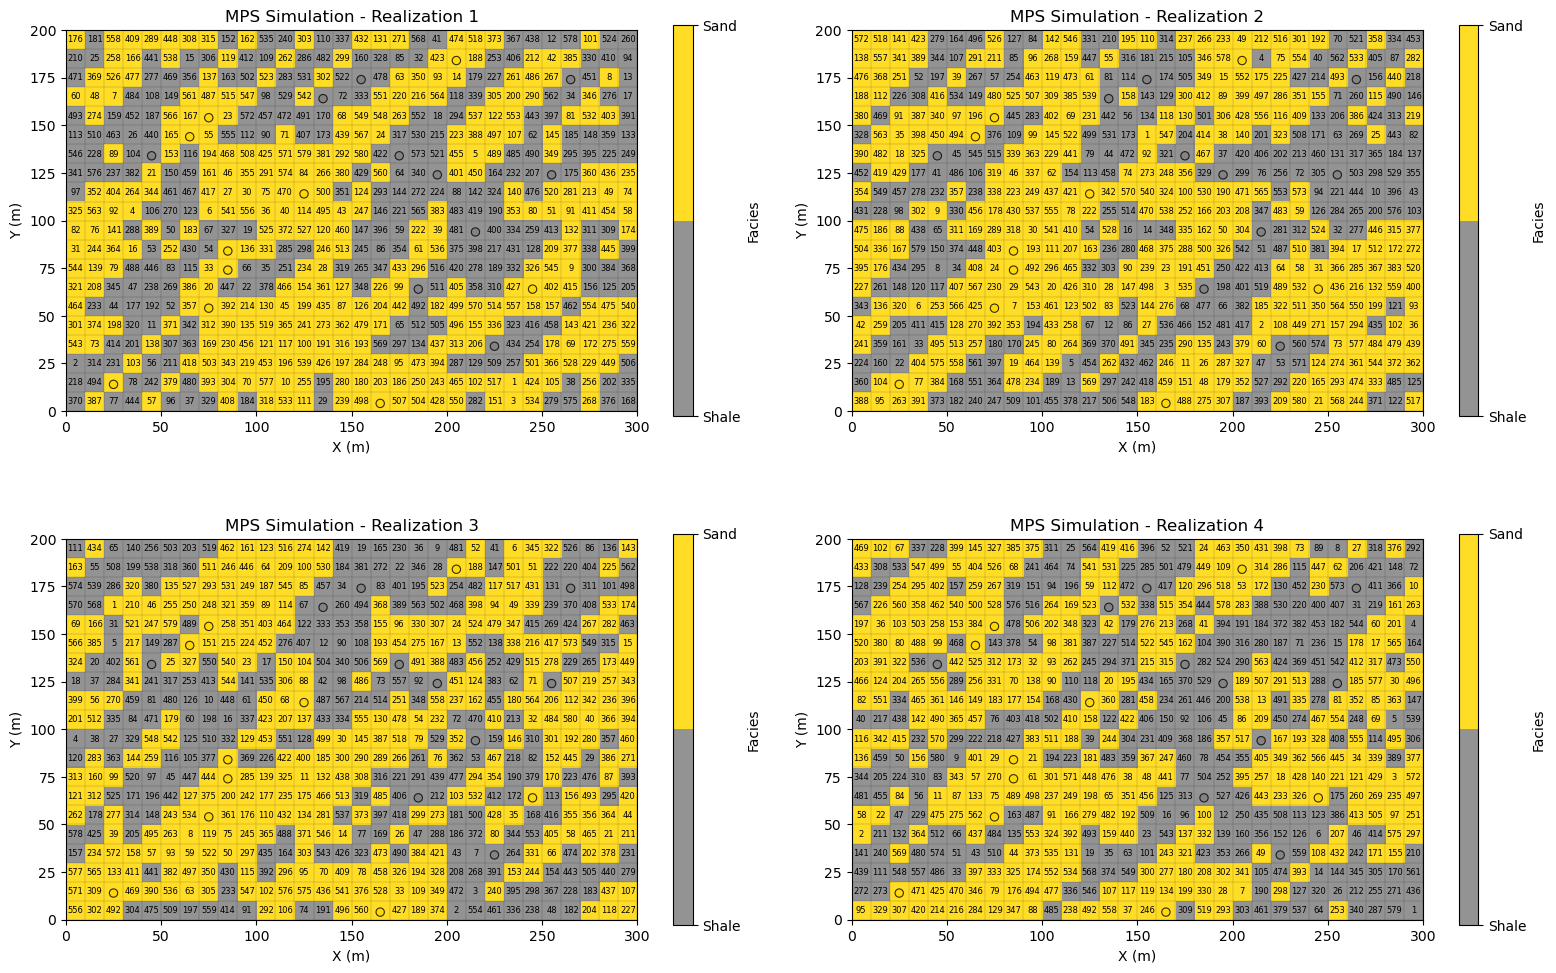

In [11]:
current_node2 = 580
seeds = [13,14,15,16]
mps_template2 = [(0, 0),(-1, 0),(1, 0),(0, 1),(0, -1),(-1, -1),(-1, 1),(1, 1),(1, -1)]

fig = plt.figure(figsize=(10,6))

for l in range(0,4):
    ax = plt.subplot(2, 2, l+1)                                    # plot the updates simulated realization
    total_step = nx*ny - len(df)
    step = total_step - current_node2
    
    sim2, unsim2, cells_empty2  = remove_unsimulated_cells_fixed(truth,df,nx,ny,xmin,xmax,ymin,ymax,n_unsim,seed=seeds[l]) # assign only data and random path
    
    cur_sim2 = np.copy(sim2)
    
    np.random.seed(seed=seeds[l])
    for inode in range(1,current_node+1):                          # fast method for MPS over all previous grid cells
        current_loc = unsim2[inode-1]
        current_mps_template = plot_mps_template(cur_sim2,mps_template2,ix=current_loc[1], iy=current_loc[0],xmin=0, xmax=300,
            ymin=0, ymax=200,title='MPS Simulation with Current Node, MPS template and Random Path',plot_template=False,cmap=cmap_facies,ax=None)
        p0, p1, nmatch, current_template = template_match_probs_drop(cur_sim2, TI, current_mps_template,ix=current_loc[1],iy=current_loc[0])
        # np.random.seed(seed=seed+inode)
        facies = sample_facies_fast(p0,p1)
        cur_sim2[current_loc[0],current_loc[1]] = facies
    
    just_plot_simulated(cur_sim2,xmin=xmin,xmax=xmax,ymin=ymin,ymax=ymax,
        title="MPS Simulation - Realization " + str(l+1),cmap=cmap_facies,ax=ax)
    plt.scatter(df['X'],df['Y'],s=None,c=df['Facies'],marker=None,cmap=cmap_facies,vmin=-0.4,vmax=1.0,alpha=0.8,
        linewidths=0.8,edgecolors="black",)
    for i, (iy, ix) in enumerate(unsim2):                         # label the random path
        k = nx*ny - (n_unsim - i) - 1
        x0 = xmin + ix * cell_size; y0 = ymin + ((ny - iy) - 1) * cell_size
        plt.text(x0 + cell_size / 2,y0 + cell_size / 2,str(i+1),ha="center",va="center",fontsize=6,color="black",)
    
    plt.vlines(x_edges, ymin, ymax, colors="k", linewidth=0.2, alpha=0.5) # grid lines
    plt.hlines(y_edges, xmin, xmax, colors="k",linewidth=0.2, alpha=0.5) 
    
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.5, top=1.5, wspace=0.1, hspace=0.3); plt.show()

#### Comments

This was a basic demonstration of multiple point simulation for a categorical feature with GeostatsPy. 

* I have potentially erred on the side of verbose and inefficient code to improve method visualizations and explainability. 

In practice, a MPS function outputs only the set of local realizations over all grid cells as a 2D / 3D array,

* I thought is was helpful to stop at any grid cell along the random path and completely vizualize the MPS method

I am happy with the result and I hope that it helps you understand MPS. Much more can be done, I have other demonstrations for modeling workflows with GeostatsPy in the GitHub repository [GeostatsPy_Demos](https://github.com/GeostatsGuy/GeostatsPy_Demos/tree/main).

I hope this is helpful,

*Michael*

#### About the Author

<figure style="text-align: center;">
  <img src="_static/intro/michael_pyrcz_officeshot_jacket.jpg" style="display: block; margin: 0 auto; width: 70%;">
  <figcaption style="text-align: center;"> Professor Michael Pyrcz in his office on the 40 acres, campus of The University of Texas at Austin.
</figcaption>
</figure>

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)